In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier

In [3]:
data = pd.read_csv(r'D:\\harsh\\Blepharospasm\\final_results.csv')

In [72]:
data.shape

(141, 22)

In [4]:
data.head(-5)

,Video Name,Left Eye Open,Left Eye Closed,Left Eye Ratio,Right Eye Open,Right Eye Closed,Right Eye Ratio,Left Not Long Blinks,Left Long Blinks,Left_Blink_Ratio,...,Right_Blink_Ratio,Left Eye Blink Frequency,Right Eye Blink Frequency,Left Eye Max Distance,Left Eye Min Distance,Right Eye Max Distance,Right Eye Min Distance,Right Eye Distance Ratio,Left Eye Distance Ratio,label
0,101,1,98,0.010204,38,61,0.622951,0,2,0.020202,...,0.010101,0.606061,1.212121,1.780108,1.132906,1.468535,1.182255,0.107998,0.222176,1
1,102,8,181,0.044199,3,186,0.016129,5,4,0.021164,...,0.010582,1.428571,0.476190,1.373957,1.067724,1.369993,1.065411,0.125064,0.125419,1
2,103,54,16,3.375000,48,22,2.181818,3,0,0.000000,...,0.014286,1.285714,0.857143,1.617521,1.264162,1.334282,1.208085,0.049637,0.122622,1
3,105,320,405,0.790123,205,520,0.394231,54,11,0.015172,...,0.019310,2.689655,1.572414,1.865418,1.141911,1.771980,1.147065,0.214082,0.240581,1
4,106,513,170,3.017647,584,99,5.898990,42,1,0.001464,...,0.001464,1.888726,1.317716,1.409633,1.250565,1.392382,1.277582,0.042997,0.059796,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,164,1433,370,3.872973,1570,233,6.738197,57,4,0.002219,...,0.001109,1.014975,0.865225,1.879288,1.494261,1.812137,1.517700,0.088424,0.114131,0
132,165,1630,173,9.421965,1606,197,8.152284,48,0,0.000000,...,0.000000,0.798669,0.782030,1.875623,1.192540,1.866194,1.189426,0.221483,0.222636,0
133,173,1313,490,2.679592,1343,460,2.919565,86,7,0.003882,...,0.004992,1.547421,1.597338,1.888109,1.171879,1.886378,1.185672,0.228091,0.234063,0
134,174,1551,252,6.154762,1757,46,38.195652,43,2,0.001109,...,0.000000,0.748752,0.332779,1.676963,1.382143,1.898916,1.551256,0.100766,0.096375,0


In [85]:
# create fina_data dataframe with variable Left Eye Ratio, Right Eye Ratio, Left_Blink_Ratio, Right_Blink_Ratio, Right Eye Distance Ratio, Left Eye Distance Ratio, label
final_data = data[['Left Eye Ratio', 'Right Eye Ratio', 'Left_Blink_Ratio', 'Right_Blink_Ratio', 'Right Eye Distance Ratio', 'Left Eye Distance Ratio', 'label']]
final_data.head(5)

,Left Eye Ratio,Right Eye Ratio,Left_Blink_Ratio,Right_Blink_Ratio,Right Eye Distance Ratio,Left Eye Distance Ratio,label
0,0.010204,0.622951,0.020202,0.010101,0.107998,0.222176,1
1,0.044199,0.016129,0.021164,0.010582,0.125064,0.125419,1
2,3.375000,2.181818,0.000000,0.014286,0.049637,0.122622,1
3,0.790123,0.394231,0.015172,0.019310,0.214082,0.240581,1
4,3.017647,5.898990,0.001464,0.001464,0.042997,0.059796,1


In [86]:
# copy final_data to copy_data
copy_data = final_data.copy()

#show correlation matrix only against label
copy_data.corr()['label'].sort_values()



Left Eye Ratio             -0.270474
Right Eye Ratio            -0.217629
Right Eye Distance Ratio   -0.132818
Left Eye Distance Ratio    -0.069310
Left_Blink_Ratio            0.550174
Right_Blink_Ratio           0.621869
label                       1.000000
Name: label, dtype: float64

In [7]:
# describe the final_data for label 0
final_data[final_data['label'] == 0].describe()

,Left Eye Ratio,Right Eye Ratio,Left_Blink_Ratio,Right_Blink_Ratio,Right Eye Displacement,Left Eye Displacement,label
count,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.0
mean,21.249790,25.967537,0.001688,0.001633,0.145143,0.143900,0.0
std,49.274350,78.068178,0.002203,0.002227,0.082517,0.071579,0.0
min,1.285171,1.500693,0.000000,0.000000,0.003053,0.019904,0.0
25%,4.388728,4.214200,0.000000,0.000000,0.083189,0.089672,0.0
50%,9.129213,9.362069,0.000555,0.000555,0.134414,0.138849,0.0
75%,16.764229,20.874963,0.002220,0.002773,0.189391,0.194698,0.0
max,359.599993,599.333313,0.008319,0.008319,0.489312,0.370270,0.0


In [8]:
#find row with minimum value of Left Eye Ratio for label 0
final_data[final_data['label'] == 0].loc[final_data[final_data['label'] == 0]['Left Eye Ratio'].idxmin()]

Left Eye Ratio            1.285171
Right Eye Ratio           1.756881
Left_Blink_Ratio          0.007210
Right_Blink_Ratio         0.008319
Right Eye Displacement    0.176875
Left Eye Displacement     0.230590
label                     0.000000
Name: 135, dtype: float64

In [9]:
# # change current value of left_blink_ratio and right_blink_ratio by multiplying by 100 in final_data dataframe
# final_data['Left_Blink_Ratio'] = final_data['Left_Blink_Ratio'] * 100
# final_data['Right_Blink_Ratio'] = final_data['Right_Blink_Ratio'] * 100



In [76]:
final_data.head(-5)

,Left Eye Ratio,Right Eye Ratio,Left_Blink_Ratio,Right_Blink_Ratio,Left Eye Max Distance,Left Eye Min Distance,Right Eye Max Distance,Right Eye Min Distance,label
0,0.010204,0.622951,0.020202,0.010101,1.780108,1.132906,1.468535,1.182255,1
1,0.044199,0.016129,0.021164,0.010582,1.373957,1.067724,1.369993,1.065411,1
2,3.375000,2.181818,0.000000,0.014286,1.617521,1.264162,1.334282,1.208085,1
3,0.790123,0.394231,0.015172,0.019310,1.865418,1.141911,1.771980,1.147065,1
4,3.017647,5.898990,0.001464,0.001464,1.409633,1.250565,1.392382,1.277582,1
...,...,...,...,...,...,...,...,...,...
131,3.872973,6.738197,0.002219,0.001109,1.879288,1.494261,1.812137,1.517700,0
132,9.421965,8.152284,0.000000,0.000000,1.875623,1.192540,1.866194,1.189426,0
133,2.679592,2.919565,0.003882,0.004992,1.888109,1.171879,1.886378,1.185672,0
134,6.154762,38.195652,0.001109,0.000000,1.676963,1.382143,1.898916,1.551256,0


In [37]:
#save fnal_data to csv file name data.csv
final_data.to_csv(r'D:\\harsh\\Blepharospasm\\data.csv', index = False)

In [11]:
final_data.shape

(141, 7)

In [87]:
# Split the dataset into training and testing sets as X_train, X_test, y_train, y_test
X = final_data.drop('label', axis=1)
y = final_data['label']

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [88]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
poly = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)

# Get feature names for the polynomial features
feature_names = poly.get_feature_names_out(input_features=X.columns)

# Create DataFrames for easy handling
X_df = pd.DataFrame(X, columns=X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=feature_names)

In [89]:
X_poly_df.head(5)

,Left Eye Ratio,Right Eye Ratio,Left_Blink_Ratio,Right_Blink_Ratio,Right Eye Distance Ratio,Left Eye Distance Ratio,Left Eye Ratio Right Eye Ratio,Left Eye Ratio Left_Blink_Ratio,Left Eye Ratio Right_Blink_Ratio,Left Eye Ratio Right Eye Distance Ratio,...,Right Eye Ratio Left_Blink_Ratio Right_Blink_Ratio,Right Eye Ratio Left_Blink_Ratio Right Eye Distance Ratio,Right Eye Ratio Left_Blink_Ratio Left Eye Distance Ratio,Right Eye Ratio Right_Blink_Ratio Right Eye Distance Ratio,Right Eye Ratio Right_Blink_Ratio Left Eye Distance Ratio,Right Eye Ratio Right Eye Distance Ratio Left Eye Distance Ratio,Left_Blink_Ratio Right_Blink_Ratio Right Eye Distance Ratio,Left_Blink_Ratio Right_Blink_Ratio Left Eye Distance Ratio,Left_Blink_Ratio Right Eye Distance Ratio Left Eye Distance Ratio,Right_Blink_Ratio Right Eye Distance Ratio Left Eye Distance Ratio
0,0.010204,0.622951,0.020202,0.010101,0.107998,0.222176,0.006357,0.000206,0.000103,0.001102,...,0.000127,0.001359,0.002796,0.000680,0.001398,0.014947,2.203820e-05,4.533741e-05,0.000485,0.000242
1,0.044199,0.016129,0.021164,0.010582,0.125064,0.125419,0.000713,0.000935,0.000468,0.005528,...,0.000004,0.000043,0.000043,0.000021,0.000021,0.000253,2.800908e-05,2.808859e-05,0.000332,0.000166
2,3.375000,2.181818,0.000000,0.014286,0.049637,0.122622,7.363636,0.000000,0.048214,0.167526,...,0.000000,0.000000,0.000000,0.001547,0.003822,0.013280,0.000000e+00,0.000000e+00,0.000000,0.000087
3,0.790123,0.394231,0.015172,0.019310,0.214082,0.240581,0.311491,0.011988,0.015258,0.169151,...,0.000116,0.001281,0.001439,0.001630,0.001831,0.020304,6.272272e-05,7.048655e-05,0.000781,0.000995
4,3.017647,5.898990,0.001464,0.001464,0.042997,0.059796,17.801070,0.004418,0.004418,0.129750,...,0.000013,0.000371,0.000516,0.000371,0.000516,0.015167,9.217192e-08,1.281824e-07,0.000004,0.000004


In [64]:
#give list of features importance for the model using Random Forest Classifier
def feature_importance(X, y):
    model = RandomForestClassifier()
    model.fit(X, y)
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    return importances, indices

importances, indices = feature_importance(X_poly, y)

# Print the feature ranking
print("Feature ranking:")
for f in range(X_poly.shape[1]):
    print(( feature_names[indices[f]], importances[indices[f]]))



Feature ranking:
('Left Eye Ratio Right Eye Ratio Left Eye Displacement', 0.13347587105098943)
('Right Eye Ratio Right Eye Displacement', 0.12174330790514779)
('Right Eye Ratio Right Eye Displacement Left Eye Displacement', 0.1098656364735916)
('Left Eye Ratio Right Eye Ratio Right Eye Displacement', 0.09065542176173959)
('Left Eye Ratio Left Eye Displacement', 0.08493308811465101)
('Left Eye Ratio Right Eye Displacement Left Eye Displacement', 0.07855994235799942)
('Right Eye Ratio Left Eye Displacement', 0.07188884270485436)
('Right Eye Ratio', 0.03624935749780271)
('Left Eye Ratio Right Eye Ratio', 0.035766678783017966)
('Right_Blink_Ratio', 0.021550340493057225)
('Left Eye Ratio', 0.020280280277744808)
('Left_Blink_Ratio', 0.019222808781828422)
('Left Eye Ratio Right Eye Displacement', 0.01908871322857136)
('Right Eye Ratio Right_Blink_Ratio', 0.012669895025850817)
('Left_Blink_Ratio Right_Blink_Ratio', 0.010250004626938144)
('Right_Blink_Ratio Right Eye Displacement Left Eye Displ

In [66]:
#correration matrix for top 10 features of X_poly_df against label
top_features = X_poly_df.columns[indices[:10]]
top_features_df = X_poly_df[top_features]
top_features_df['label'] = y
corr_matrix = top_features_df.corr()
corr_matrix

C:\Users\harsh\AppData\Local\Temp\ipykernel_2252\3981419920.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_features_df['label'] = y


,Left Eye Ratio Right Eye Ratio Left Eye Displacement,Right Eye Ratio Right Eye Displacement,Right Eye Ratio Right Eye Displacement Left Eye Displacement,Left Eye Ratio Right Eye Ratio Right Eye Displacement,Left Eye Ratio Left Eye Displacement,Left Eye Ratio Right Eye Displacement Left Eye Displacement,Right Eye Ratio Left Eye Displacement,Right Eye Ratio,Left Eye Ratio Right Eye Ratio,Right_Blink_Ratio,label
Left Eye Ratio Right Eye Ratio Left Eye Displacement,1.000000,0.531651,0.179846,0.918429,0.726574,0.211895,0.744526,0.805105,0.935191,-0.134222,-0.153011
Right Eye Ratio Right Eye Displacement,0.531651,1.000000,0.833792,0.611382,0.796959,0.727110,0.819176,0.402775,0.382689,-0.412651,-0.494738
Right Eye Ratio Right Eye Displacement Left Eye Displacement,0.179846,0.833792,1.000000,0.240193,0.593138,0.858129,0.664065,0.166640,0.082715,-0.379140,-0.496464
Left Eye Ratio Right Eye Ratio Right Eye Displacement,0.918429,0.611382,0.240193,1.000000,0.769757,0.287625,0.630272,0.520197,0.721400,-0.127580,-0.145753
Left Eye Ratio Left Eye Displacement,0.726574,0.796959,0.593138,0.769757,1.000000,0.736790,0.814378,0.523436,0.576760,-0.366738,-0.469944
Left Eye Ratio Right Eye Displacement Left Eye Displacement,0.211895,0.727110,0.858129,0.287625,0.736790,1.000000,0.563793,0.147343,0.105815,-0.360384,-0.525082
Right Eye Ratio Left Eye Displacement,0.744526,0.819176,0.664065,0.630272,0.814378,0.563793,1.000000,0.780140,0.723965,-0.399834,-0.477827
Right Eye Ratio,0.805105,0.402775,0.166640,0.520197,0.523436,0.147343,0.780140,1.000000,0.947439,-0.193900,-0.217629
Left Eye Ratio Right Eye Ratio,0.935191,0.382689,0.082715,0.721400,0.576760,0.105815,0.723965,0.947439,1.000000,-0.115643,-0.130876
Right_Blink_Ratio,-0.134222,-0.412651,-0.379140,-0.127580,-0.366738,-0.360384,-0.399834,-0.193900,-0.115643,1.000000,0.621869


In [90]:
X_train, X_test, y_train, y_test = train_test_split(X_poly_df, y, test_size=0.25, random_state=42)

In [91]:
import numpy as np
np.random.seed(42)
import random
random.seed(42)


In [92]:
from sklearn.model_selection import RepeatedKFold

rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)


In [93]:
# Standardize the data
scaler = StandardScaler()

# Define models to test
models = {
    'RandomForest': RandomForestClassifier(max_depth=None, n_estimators=200),
    'SVM': SVC(C=1, gamma=0.1, kernel='rbf'),
    'LogisticRegression': LogisticRegression(C=10, solver='liblinear'),
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(max_depth=30),
    'MLP': MLPClassifier(activation='relu', hidden_layer_sizes=(100,), solver='sgd', max_iter=2000)
}


# Create a pipeline for each model and use regularized cross-validation to evaluate the model

pipelines = {name: Pipeline([('scaler', scaler), ('model', model)]) for name, model in models.items()}


In [94]:
results = {}
for model_name, model in pipelines.items():
    model_scores = cross_val_score(model, X_train, y_train, cv=rkf, scoring='accuracy')
    results[model_name] = {
        'mean_score': np.mean(model_scores),
        'std_score': np.std(model_scores)
    }

for model_name, scores in results.items():
    print(f"{model_name} - Mean Score: {scores['mean_score']:.4f}")

RandomForest - Mean Score: 0.9305
SVM - Mean Score: 0.8029
LogisticRegression - Mean Score: 0.8924
KNN - Mean Score: 0.8781
DecisionTree - Mean Score: 0.8876
MLP - Mean Score: 0.8933


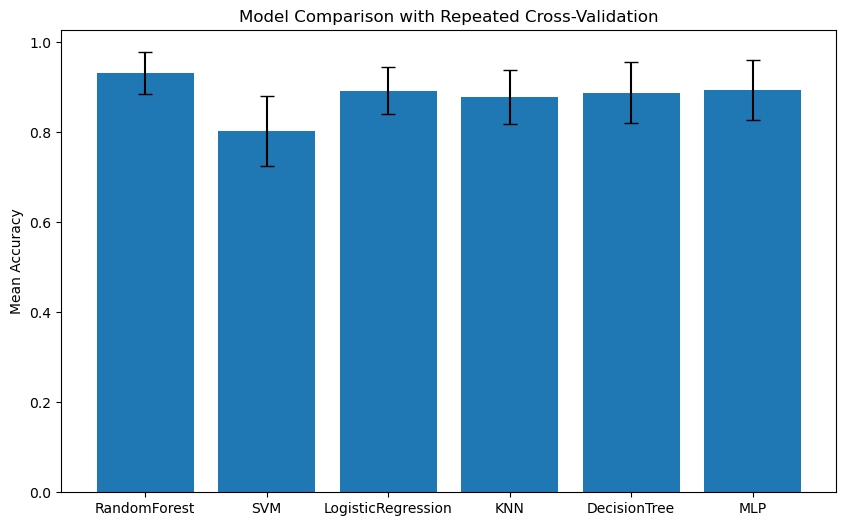

In [47]:
import matplotlib.pyplot as plt

model_names = list(results.keys())
mean_scores = [results[model]['mean_score'] for model in model_names]
std_scores = [results[model]['std_score'] for model in model_names]

plt.figure(figsize=(10, 6))
plt.bar(model_names, mean_scores, yerr=std_scores, capsize=5)
plt.ylabel('Mean Accuracy')
plt.title('Model Comparison with Repeated Cross-Validation')
plt.show()


In [48]:
cv_results = {}
for name, pipeline in pipelines.items():
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=rkf, scoring='accuracy')
    cv_results[name] = cv_scores.mean()

    #print(f'{name} CV average score: {cv_scores.mean()}')
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    #print average score and test accuracy of each model in a single line
    print(f'{name} CV average score: {cv_scores.mean()}', f'Test accuracy: {pipeline.score(X_test, y_test)}')
    


RandomForest CV average score: 0.9304761904761903 Test accuracy: 0.9722222222222222
SVM CV average score: 0.8028571428571426 Test accuracy: 0.8333333333333334
LogisticRegression CV average score: 0.8923809523809523 Test accuracy: 0.8888888888888888
KNN CV average score: 0.8780952380952379 Test accuracy: 0.8333333333333334
DecisionTree CV average score: 0.8771428571428571 Test accuracy: 0.8888888888888888
MLP CV average score: 0.8904761904761904 Test accuracy: 0.9444444444444444


In [22]:
# #print training and testing accuracy of each model
# cv_results

In [23]:
# Example parameter grids (customize these based on your requirements)
param_grids = {
    'RandomForest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 10, 20, 30]
    },
    'SVM': {
        'model__C': [0.1, 1, 10],
        'model__gamma': [1, 0.1, 0.01],
        'model__kernel': ['rbf', 'linear']
    },
    'LogisticRegression': {
        'model__C': [0.1, 1, 10],
        'model__solver': ['liblinear', 'saga']
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7],
        'model__weights': ['uniform', 'distance']
    },
    'DecisionTree': {
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10]
    },
    'AdaBoost': {
        'model__n_estimators': [50, 100, 200],
        'model__learning_rate': [0.01, 0.1, 1]
    },
    'MLP': {
        'model__hidden_layer_sizes': [(50,), (100,)],
        'model__activation': ['relu', 'tanh'],
        'model__solver': ['adam', 'sgd']
    }
}

In [24]:
# Perform GridSearchCV for each model
best_estimators = {}
for name, pipeline in pipelines.items():
    grid_search = GridSearchCV(pipeline, param_grids[name], cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_estimators[name] = grid_search.best_estimator_
    print(f'{name} best parameters: {grid_search.best_params_}')
    print(f'{name} best score: {grid_search.best_score_}')

RandomForest best parameters: {'model__max_depth': None, 'model__n_estimators': 200}
RandomForest best score: 0.9523809523809523
SVM best parameters: {'model__C': 10, 'model__gamma': 1, 'model__kernel': 'linear'}
SVM best score: 0.9047619047619048
LogisticRegression best parameters: {'model__C': 0.1, 'model__solver': 'saga'}
LogisticRegression best score: 0.8857142857142858
KNN best parameters: {'model__n_neighbors': 3, 'model__weights': 'uniform'}
KNN best score: 0.8476190476190476
DecisionTree best parameters: {'model__max_depth': 10, 'model__min_samples_split': 5}
DecisionTree best score: 0.9619047619047618
MLP best parameters: {'model__activation': 'relu', 'model__hidden_layer_sizes': (100,), 'model__solver': 'adam'}
MLP best score: 0.8761904761904761


In [25]:
#print confusion matrix and classification report for each model
for name, pipeline in best_estimators.items():
    y_pred = pipeline.predict(X_test)
    print(f'{name} confusion matrix:')
    print(confusion_matrix(y_test, y_pred))
    print(f'{name} classification report:')
    print(classification_report(y_test, y_pred))

    

RandomForest confusion matrix:
[[15  1]
 [ 1 19]]
RandomForest classification report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        16
           1       0.95      0.95      0.95        20

    accuracy                           0.94        36
   macro avg       0.94      0.94      0.94        36
weighted avg       0.94      0.94      0.94        36

SVM confusion matrix:
[[13  3]
 [ 1 19]]
SVM classification report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87        16
           1       0.86      0.95      0.90        20

    accuracy                           0.89        36
   macro avg       0.90      0.88      0.89        36
weighted avg       0.89      0.89      0.89        36

LogisticRegression confusion matrix:
[[15  1]
 [ 3 17]]
LogisticRegression classification report:
              precision    recall  f1-score   support

           0       0.83      0.94      

In [26]:
#find out best estimator with maximum grid_search.best_score_
best_estimator = max(best_estimators, key=lambda x: grid_search.best_score_)
print(f'Best estimator: {best_estimator}')

Best estimator: RandomForest


In [27]:
# how to find out which data random forest is classifying wrong
y_pred = best_estimators['RandomForest'].predict(X_test)
wrong_predictions = X_test[y_pred != y_test]
wrong_predictions['label'] = y_test[y_pred != y_test]
wrong_predictions


C:\Users\harsh\AppData\Local\Temp\ipykernel_2252\299240904.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wrong_predictions['label'] = y_test[y_pred != y_test]


,Left Eye Ratio,Right Eye Ratio,Left_Blink_Ratio,Right_Blink_Ratio,Right Eye Displacement,Left Eye Displacement,Left Eye Ratio Right Eye Ratio,Left Eye Ratio Left_Blink_Ratio,Left Eye Ratio Right_Blink_Ratio,Left Eye Ratio Right Eye Displacement,...,Right Eye Ratio Right_Blink_Ratio,Right Eye Ratio Right Eye Displacement,Right Eye Ratio Left Eye Displacement,Left_Blink_Ratio Right_Blink_Ratio,Left_Blink_Ratio Right Eye Displacement,Left_Blink_Ratio Left Eye Displacement,Right_Blink_Ratio Right Eye Displacement,Right_Blink_Ratio Left Eye Displacement,Right Eye Displacement Left Eye Displacement,label
95,3.582697,4.160458,0.000555,0.00000,0.182422,0.068935,14.905663,0.001989,0.000000,0.653562,...,0.000000,0.758958,0.286803,0.0,0.000101,0.000038,0.000000,0.000000,0.012575,0
55,3.986486,4.765625,0.000000,0.00271,0.061789,0.086203,18.998100,0.000000,0.010803,0.246320,...,0.012915,0.294462,0.410809,0.0,0.000000,0.000000,0.000167,0.000234,0.005326,1


In [28]:
# Choose the best model (based on validation scores)
best_model_name = max(cv_results, key=cv_results.get)
best_model = best_estimators[best_model_name]

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Evaluate the model
print(f'Best Model: {best_model_name}')
print(classification_report(y_test, y_pred))



Best Model: RandomForest
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        16
           1       0.95      0.95      0.95        20

    accuracy                           0.94        36
   macro avg       0.94      0.94      0.94        36
weighted avg       0.94      0.94      0.94        36



In [29]:
print(best_estimators.items())

dict_items([('RandomForest', Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(n_estimators=200))])), ('SVM', Pipeline(steps=[('scaler', StandardScaler()),
                ('model', SVC(C=10, gamma=1, kernel='linear'))])), ('LogisticRegression', Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(C=0.1, solver='saga'))])), ('KNN', Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=3))])), ('DecisionTree', Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 DecisionTreeClassifier(max_depth=10, min_samples_split=5))])), ('MLP', Pipeline(steps=[('scaler', StandardScaler()),
                ('model', MLPClassifier(max_iter=2000))]))])


Evaluation for RandomForest:
Accuracy: 0.9444444444444444
Precision: 0.9444444444444444
Recall: 0.9444444444444444
F1 Score: 0.9444444444444444


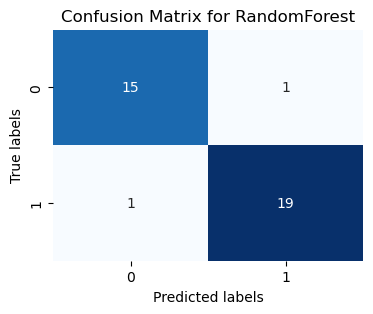

Evaluation for SVM:
Accuracy: 0.8888888888888888
Precision: 0.8924963924963925
Recall: 0.8888888888888888
F1 Score: 0.8878306878306879


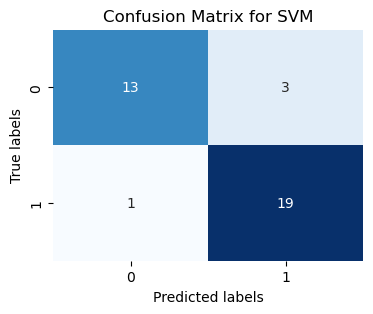

Evaluation for LogisticRegression:
Accuracy: 0.8888888888888888
Precision: 0.8950617283950617
Recall: 0.8888888888888888
F1 Score: 0.889232886136911


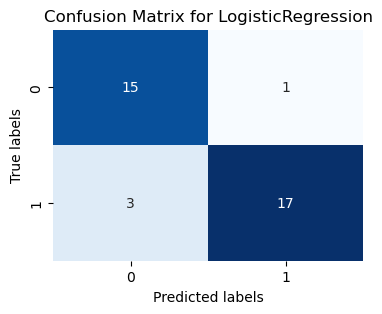

Evaluation for KNN:
Accuracy: 0.8055555555555556
Precision: 0.8176814585483316
Recall: 0.8055555555555556
F1 Score: 0.8060060060060059


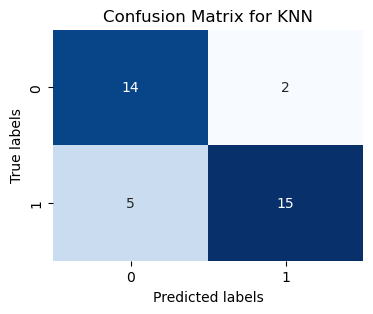

Evaluation for DecisionTree:
Accuracy: 0.8333333333333334
Precision: 0.8354978354978354
Recall: 0.8333333333333334
F1 Score: 0.8317460317460318


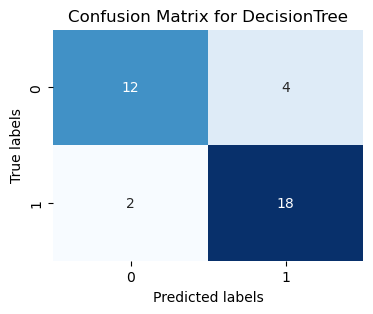

Evaluation for MLP:
Accuracy: 0.9166666666666666
Precision: 0.9184726522187822
Recall: 0.9166666666666666
F1 Score: 0.9168609168609169


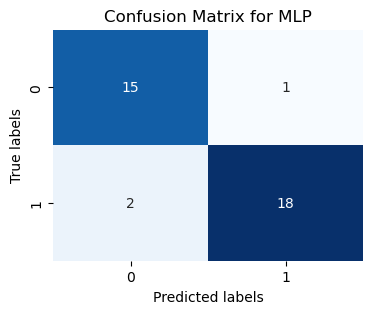

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Function to evaluate model
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Evaluation for {name}:")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    
    # Plot confusion matrix
    cm_df = pd.DataFrame(cm, index=np.unique(y_test), columns=np.unique(y_test))
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues', cbar=False)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

# Evaluate each best model
for name, model in best_estimators.items():
    evaluate_model(name, model, X_test, y_test)


In [31]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np


In [32]:
def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    if axes is None:
        fig, axes = plt.subplots(1, 1, figsize=(10, 6))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Training examples")
    axes.set_ylabel("Score")

    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
    axes.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    axes.legend(loc="best")
    return plt


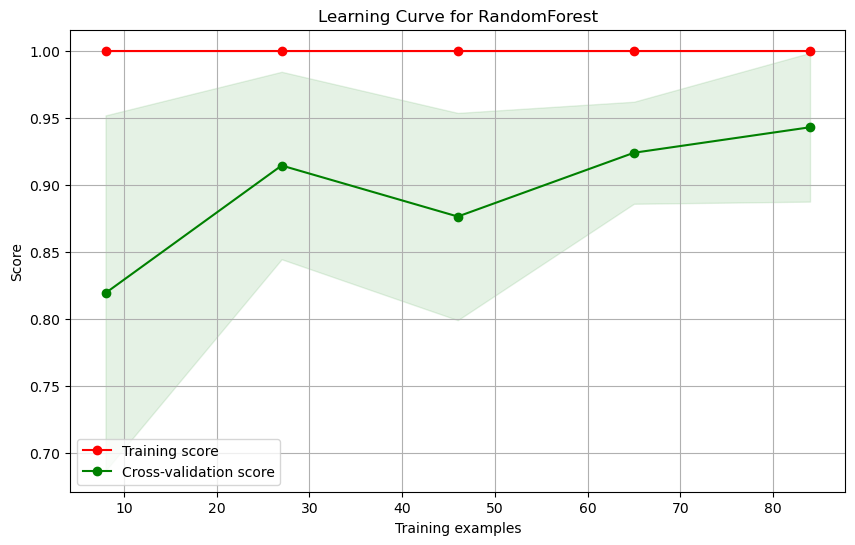

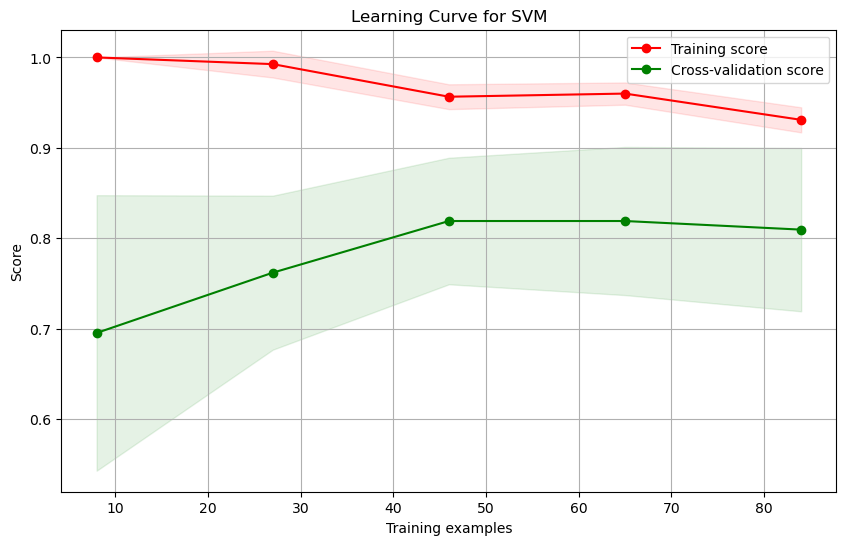

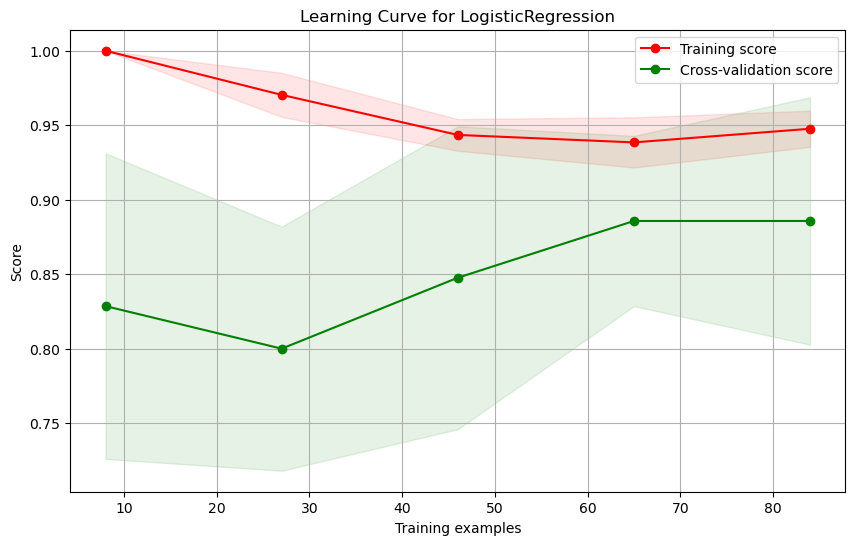

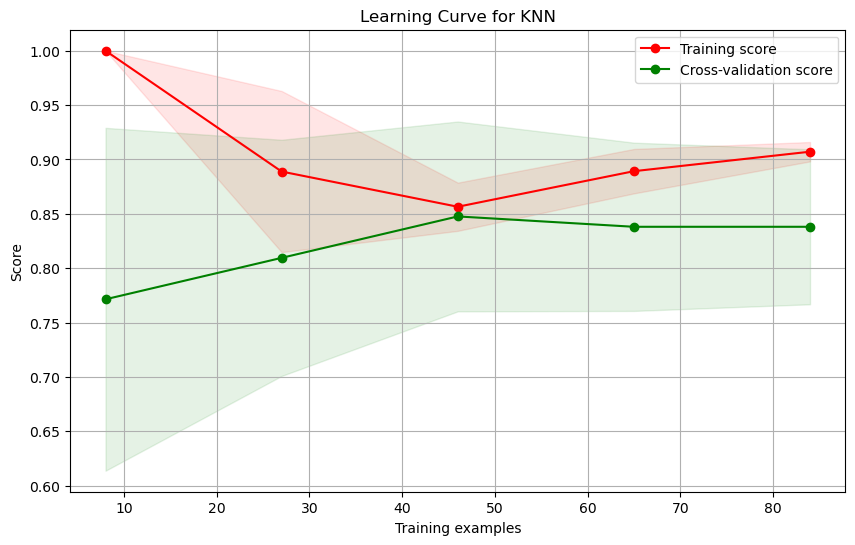

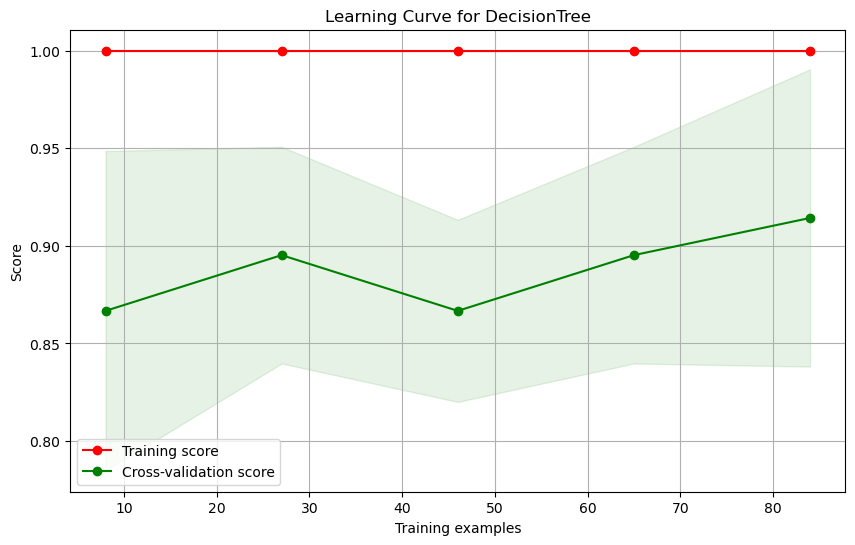

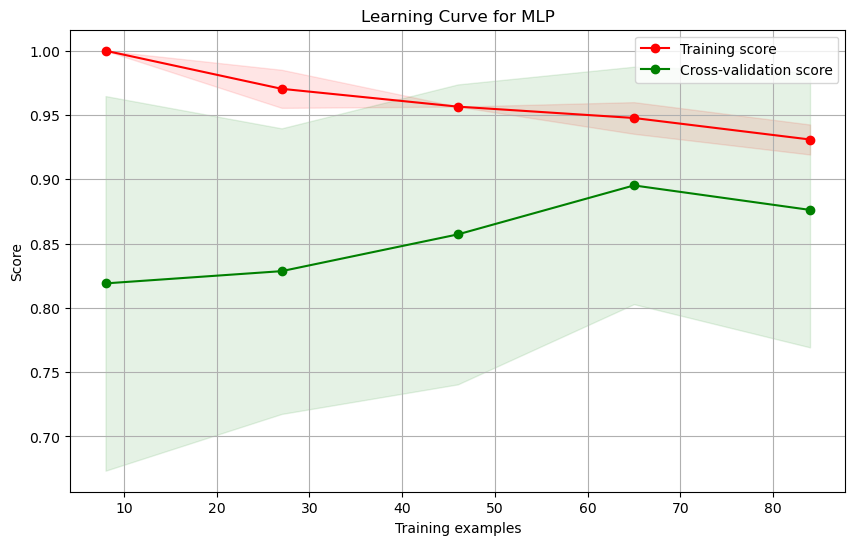

In [33]:
from sklearn.model_selection import StratifiedKFold

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5)

# Plot learning curves for each model
for name, pipeline in pipelines.items():
    plot_learning_curve(pipeline, f'Learning Curve for {name}', X_train, y_train, cv=cv, n_jobs=-1)
    plt.show()
